In [1]:
import sys
import os
print(sys.executable)
SRC_SUBDIR = '../..'
SRC_SUBDIR = os.path.abspath(SRC_SUBDIR)
if SRC_SUBDIR not in sys.path:
    print(f'Adding source directory to the sys.path: {SRC_SUBDIR!r}')
    sys.path.insert(1, SRC_SUBDIR)

/opt/homebrew/Caskroom/miniforge/base/envs/nlops/bin/python
Adding source directory to the sys.path: '/Volumes/Data/Projects/NLOperators'


In [2]:
import matplotlib.pyplot as plt
from SIRModelling import SIRModel

In [3]:
Npopulation = 1.0e6
sirmod = SIRModel(T = 280.0, dt =0.1, Tsub =1.0)
tvalues = sirmod.tvalues

In [4]:
import numpy as np
i0=1/Npopulation
s0 = 1-i0
data = sirmod(np.array([s0, i0, 0.2, 0.1, 1, 0]))
print(f"{data.shape=}")

data.shape=(280, 3)


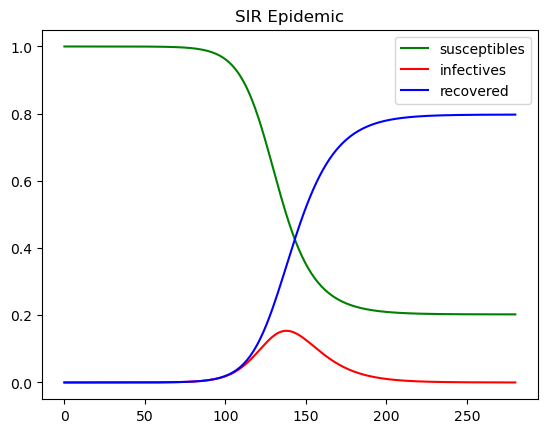

In [5]:
susceptibles = data[:,0]
infectives   = data[:,1]
recovered    = data[:,2]
plt.plot(tvalues, susceptibles, label="susceptibles", color="green")
plt.plot(tvalues, infectives, label="infectives", color="red")
plt.plot(tvalues, recovered, label="recovered", color="blue")
plt.title("SIR Epidemic")
plt.legend()

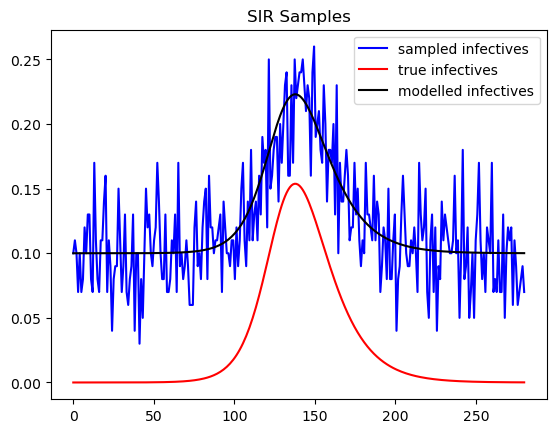

In [10]:
from SIRModelling import sample
nsamples = 100
ptp = 0.9
pfp = 0.1
positives = sample(infectives, ptp, pfp, nsamples)
modelled = ptp*infectives + pfp*(1-infectives)
plt.plot(tvalues, positives/nsamples, label="sampled infectives", color="blue")
plt.plot(tvalues, infectives, label="true infectives", color="red")
plt.plot(tvalues, modelled, label="modelled infectives", color="black")
plt.title("SIR Samples")
plt.legend()
